# Task 1: Laying the Foundation for Analysis

## Brent Oil Prices Change Point Analysis

### Project Objective

The objective of this project is to analyze historical Brent crude oil prices and identify significant market changes caused by economic, geopolitical, and industry events.

The analysis workflow includes:

1. Loading and understanding the Brent oil price dataset.
2. Performing data quality assessment.
3. Cleaning and preparing the data.
4. Exploring historical price trends.
5. Identifying volatility patterns and possible structural changes.
6. Connecting price movements with major global events.

The final goal is to build a foundation for statistical modeling and change point detection.

## Data Analysis Workflow

The analysis follows these major steps:

### Step 1: Data Loading
- Import Brent oil price data.
- Convert date fields into proper datetime format.
- Validate dataset structure.

### Step 2: Data Quality Assessment
- Check missing values.
- Identify duplicated records.
- Validate data types.
- Detect abnormal values.

### Step 3: Exploratory Data Analysis
- Analyze descriptive statistics.
- Understand price distribution.
- Examine historical trends.

### Step 4: Visualization
- Plot historical Brent prices.
- Analyze price movements.
- Identify periods of high volatility.

### Step 5: Event Research
Collect important economic and geopolitical events that may explain major price changes.

### Step 6: Modeling Preparation
Prepare cleaned data for:
- Change point detection
- Statistical modeling
- Forecasting

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

import sys

# Add project root to python path

sys.path.append("../")


print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Import project modules

from src.data_loader import (
    load_brent_data,
    convert_date_column
)

from src.preprocessing import (
    create_price_features
)

from src.eda import (
    dataset_overview,
    summary_statistics,
    price_range,
    adf_test
)

from src.visualization import (
    plot_price_history,
    plot_price_distribution,
    plot_price_change,
    plot_volatility
)


print("Project modules imported successfully")

Project modules imported successfully


In [3]:
DATA_PATH = "../data/BrentOilPrices.csv"


df = load_brent_data(
    DATA_PATH
)


df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


In [4]:
# Dataset shape
print(
    "Dataset Shape:"
)

print(df.shape)

Dataset Shape:
(9011, 2)


In [5]:
# Display column names

df.columns

Index(['Date', 'Price'], dtype='object')

In [6]:
# Convert Date column

df = convert_date_column(
    df,
    date_column="Date"
)


df.head()


c:\Users\edenteklehaimanot\Downloads\brent-oil-change-point-analysis\notebooks\..\src\data_loader.py:84: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_column] = pd.to_datetime(


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[ns]
 1   Price   9011 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 140.9 KB


In [8]:
overview = dataset_overview(
    df
)
overview

{'rows': 9011,
 'columns': 2,
 'column_names': ['Date', 'Price'],
 'missing_values': {'Date': 0, 'Price': 0},
 'duplicates': np.int64(0)}

In [9]:
summary_statistics(
    df
)

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958720,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


In [10]:
df = create_price_features(
    df
)


df.head()

,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Mean_30,Rolling_Volatility
0,1987-05-20,18.63,2.924773,NaN,NaN,NaN,NaN
1,1987-05-21,18.45,2.915064,-0.18,-0.009709,NaN,NaN
2,1987-05-22,18.55,2.920470,0.10,0.005405,NaN,NaN
3,1987-05-25,18.60,2.923162,0.05,0.002692,NaN,NaN
4,1987-05-26,18.63,2.924773,0.03,0.001612,NaN,NaN


In [11]:
price_range(df)

{'minimum_price': np.float64(9.1),
 'maximum_price': np.float64(143.95),
 'average_price': np.float64(48.42078237709467)}

In [12]:
df.describe()

,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Mean_30,Rolling_Volatility
count,9011,9011.000000,9011.000000,9010.000000,9010.000000,8981.000000,8981.000000
mean,2005-02-10 23:46:53.760958720,48.420782,3.638729,0.008320,0.000179,0.000180,0.021564
min,1987-05-20 00:00:00,9.100000,2.208274,-16.600000,-0.643699,-0.053648,0.005807
25%,1996-03-20 12:00:00,19.050000,2.947067,-0.390000,-0.011154,-0.002191,0.014916
50%,2005-02-02 00:00:00,38.570000,3.652475,0.020000,0.000402,0.000403,0.019305
75%,2014-01-09 12:00:00,70.090000,4.249780,0.450000,0.012127,0.002827,0.024429
max,2022-11-14 00:00:00,143.950000,4.969466,10.450000,0.412023,0.047928,0.187314
std,NaN,32.860110,0.707122,1.216227,0.025532,0.004820,0.013661


In [13]:
  # Perform ADF test on the Brent Oil Price series
adf_test(df['Price'], 'Brent Oil Price')



--- Augmented Dickey-Fuller Test for Brent Oil Price ---
ADF Statistic: -1.9939
P-value: 0.2893
Critical Values:
    1%: -3.4311
    5%: -2.8619
    10%: -2.5669
Result: Fail to reject H0 (Series is non-stationary)


In [14]:

    # It's common for price series to be non-stationary. Often, log returns are stationary.
    # Let's test Log_Return as well (ensure to drop NaNs from Log_Return first)
adf_test(df['Log_Return'], 'Brent Oil Log Returns')


--- Augmented Dickey-Fuller Test for Brent Oil Log Returns ---
ADF Statistic: -16.4271
P-value: 0.0000
Critical Values:
    1%: -3.4311
    5%: -2.8619
    10%: -2.5669
Result: Reject H0 (Series is stationary)


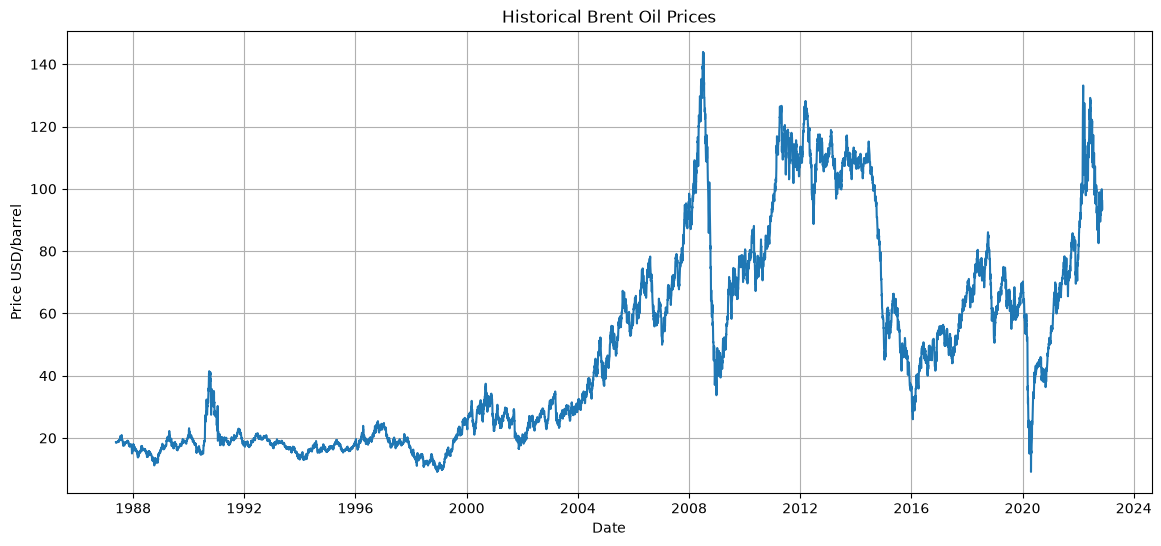

In [15]:
plot_price_history(
    df
)

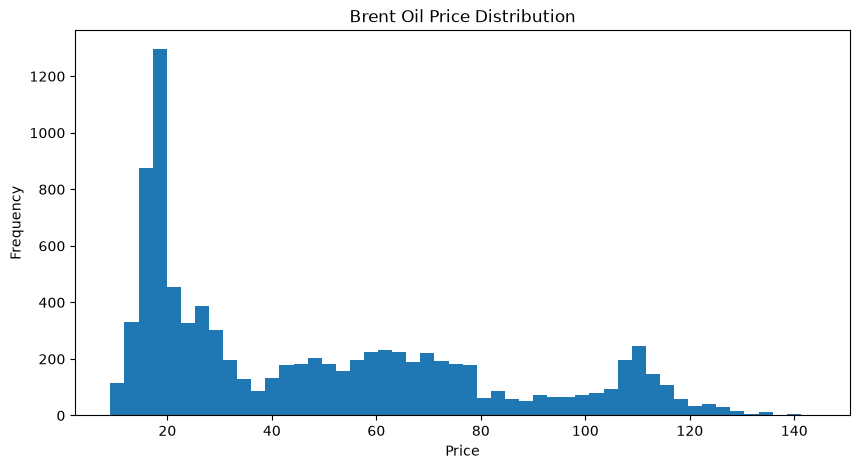

In [16]:
plot_price_distribution(df)

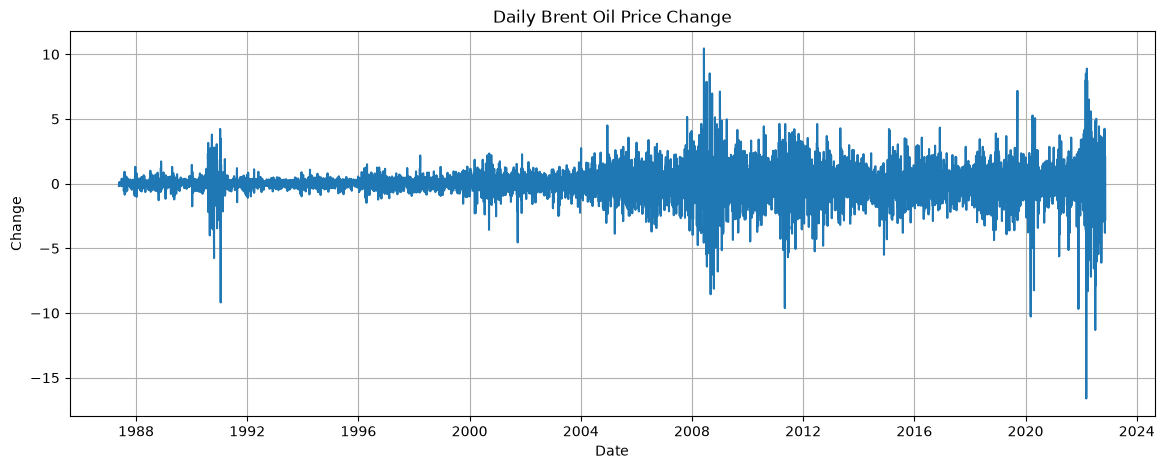

In [17]:
plot_price_change(df)

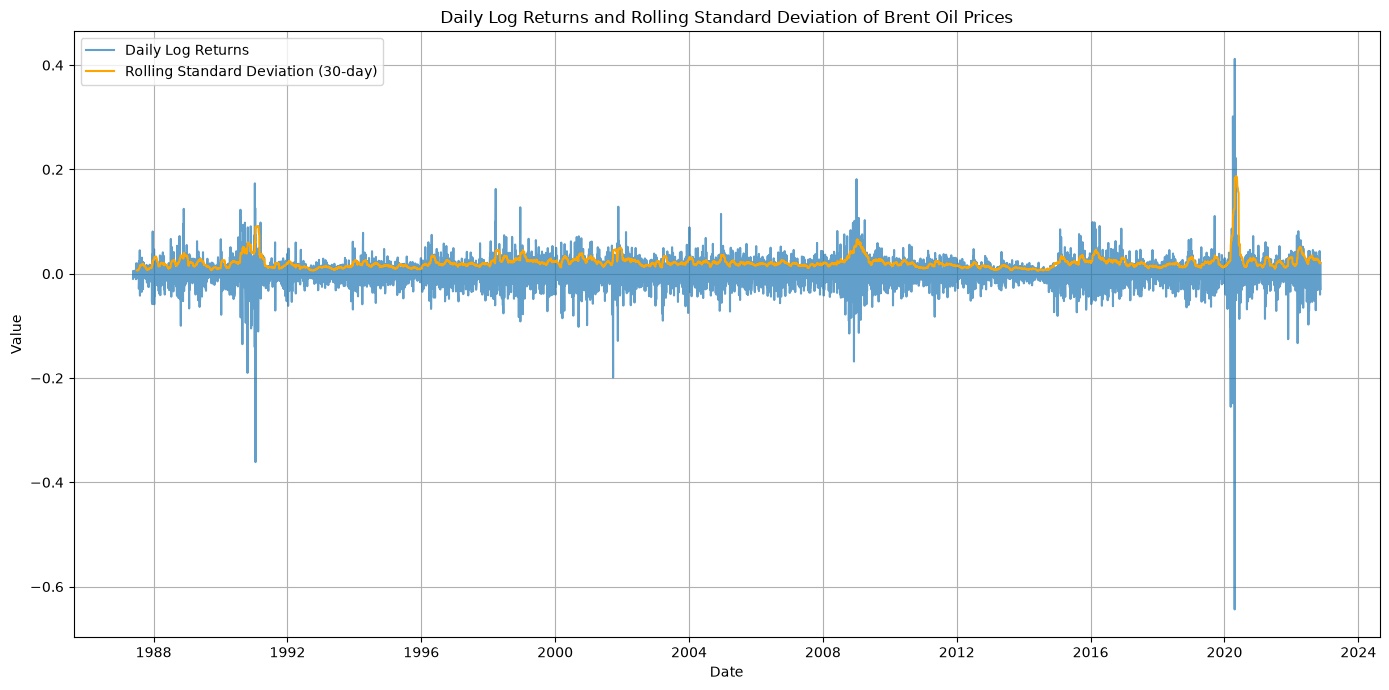

In [18]:
plot_volatility(df)

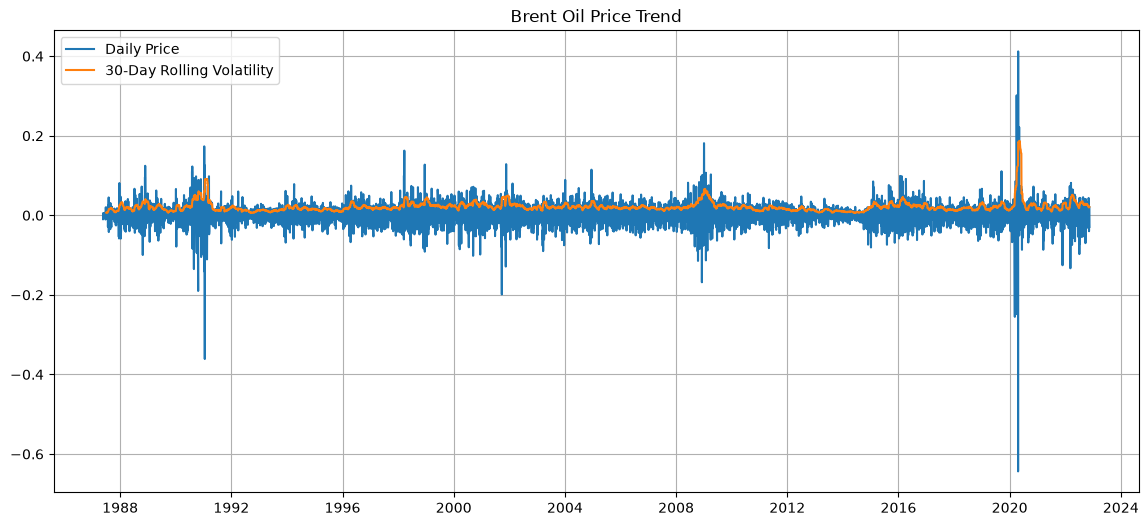

In [23]:
plt.figure(figsize=(14,6))


plt.plot(
    df["Date"],
    df["Log_Return"],
    label="Daily Price"
)


plt.plot(
    df["Date"],
    df["Rolling_Volatility"],
    label="30-Day Rolling Volatility"
)


plt.title(
    "Brent Oil Price Trend"
)


plt.legend()

plt.grid(True)

plt.show()

In [20]:
df.describe()

,Date,Price,Log_Price,Price_Change,Log_Return,Rolling_Mean_30,Rolling_Volatility
count,9011,9011.000000,9011.000000,9010.000000,9010.000000,8981.000000,8981.000000
mean,2005-02-10 23:46:53.760958720,48.420782,3.638729,0.008320,0.000179,0.000180,0.021564
min,1987-05-20 00:00:00,9.100000,2.208274,-16.600000,-0.643699,-0.053648,0.005807
25%,1996-03-20 12:00:00,19.050000,2.947067,-0.390000,-0.011154,-0.002191,0.014916
50%,2005-02-02 00:00:00,38.570000,3.652475,0.020000,0.000402,0.000403,0.019305
75%,2014-01-09 12:00:00,70.090000,4.249780,0.450000,0.012127,0.002827,0.024429
max,2022-11-14 00:00:00,143.950000,4.969466,10.450000,0.412023,0.047928,0.187314
std,NaN,32.860110,0.707122,1.216227,0.025532,0.004820,0.013661


In [21]:
missing_values = df.isnull().sum()

missing_values

Date                   0
Price                  0
Log_Price              0
Price_Change           1
Log_Return             1
Rolling_Mean_30       30
Rolling_Volatility    30
dtype: int64

In [22]:
OUTPUT_PATH = "../data/brent_processed.csv"


df.to_csv(
    OUTPUT_PATH,
    index=False
)


print(
    "Processed dataset saved successfully:"
)

print(
    OUTPUT_PATH
)

Processed dataset saved successfully:
../data/brent_processed.csv


Assumptions and Limitations
Assumptions:

Data Accuracy: We assume the Brent oil price data from the provided CSV file is accurate and reflects historical market prices without significant errors or manipulation.
Market Efficiency (relative): While markets are complex, we assume that major geopolitical and economic events are eventually reflected in oil prices, allowing for a retrospective analysis of their impact.
Log-normality of Returns: For certain statistical analyses and models (e.g., Black-Scholes for options pricing, or some GARCH models), log returns are often assumed to be approximately normally distributed. While this may not hold perfectly, it's a common simplifying assumption.
Event Data Relevance: We assume that the selected major events are indeed relevant drivers of oil price fluctuations and that their approximate start dates are sufficient for identifying potential impacts.
Limitations:

Data Granularity: The daily frequency of the data might miss intra-day fluctuations or very short-term impacts of events. Higher frequency data could reveal different dynamics.
External Factors: Oil prices are influenced by a vast array of complex and interacting factors (supply, demand, geopolitical tensions, technological advancements, economic growth, speculation, alternative energy policies, etc.). This analysis will focus on identifying when changes occur, but attributing them definitively to a single cause can be challenging.
Model Simplifications: Any statistical model is a simplification of reality. The models chosen will have inherent assumptions and might not capture all nuances of oil price behavior.
Forecasting Horizon: The reliability of any forecasting model will decrease with longer horizons, especially in a volatile market like crude oil.
Statistical Correlation vs. Causal Impact:

It is crucial to distinguish between identifying a statistical correlation in time and proving a causal impact. A change point detected after a major event suggests a correlation or temporal proximity, but it does not prove that the event caused the change. Other confounding factors might be at play, or the event itself might be a symptom of broader underlying shifts. Proving causation in economics and finance is exceptionally difficult and usually requires more rigorous econometric techniques (e.g., Granger causality tests, controlled experiments which are impossible with historical data, or advanced causal inference methods) and a deep theoretical understanding of the mechanisms. This analysis aims to identify potential points of influence rather than establish definitive causal links.

Explaining Change Point Models
Change point models are statistical tools designed to detect abrupt shifts or structural breaks in the properties of a time series. These shifts can manifest in various ways, such as a sudden change in the mean, variance, trend, or even the underlying statistical distribution of the data. In the context of Brent oil prices, change points can help identify specific dates or periods when the market dynamics fundamentally altered, potentially due to external events.

Purpose:

Identify Structural Breaks: Unlike traditional time series models that assume constant parameters, change point models explicitly search for points where these parameters change.
Segmentation: They effectively segment a time series into different regimes, where each segment exhibits relatively stable statistical properties.
Event Attribution: By comparing identified change points with historical event data, we can gain insights into the potential impact of those events on oil prices.
Improved Modeling: Understanding structural breaks can lead to more robust forecasting models by allowing different models or parameters for different regimes.
How they work (general concept):

Most change point algorithms operate by comparing statistical properties (e.g., mean, variance) of segments of the data. They scan the series, often using a sliding window or a binary segmentation approach, and calculate a 'cost' function that quantifies how well the current segment fits a certain model. A large deviation in this cost function, or a significant difference in properties between adjacent segments, indicates a potential change point. Statistical tests (like CUSUM tests or likelihood ratio tests) are then used to determine the significance of these detected changes.

Expected Outputs and Limitations of Change Point Analysis
Expected Outputs:

Dates of Change Points: The primary output will be a list of specific dates (or date ranges) where significant changes in the Brent oil price series' properties are detected.
New Parameter Values: For each detected segment, the model might provide estimates of the new parameters (e.g., the average price level, volatility, or trend slope) within that regime.
Statistical Significance: Many algorithms provide a measure of the statistical significance of each detected change point, indicating the confidence in the identified break.
Segmentation of the Time Series: A visual representation of the original time series divided into distinct segments by the identified change points.
Limitations:

Multiple Change Points: Identifying too many change points can lead to overfitting and make interpretation difficult. Conversely, too few might miss important structural breaks.
Sensitivity to Parameters: The results can be sensitive to the choice of algorithm, penalty parameters (which control the number of change points), and the type of change being sought (mean, variance, etc.).
False Positives: Random fluctuations or outliers can sometimes be misidentified as change points, especially in noisy data.
Causality vs. Correlation: As discussed earlier, change point analysis identifies when changes occur, not necessarily why. Attributing a change point to a specific event requires careful external analysis and domain knowledge.
Data Quality: The presence of missing values, errors, or extreme outliers in the input data can significantly affect the accuracy and reliability of change point detection.